In [1]:
from pathlib import Path

csv_paths = {
    "102-string": Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/TriggeredEventList/340StringMC/102_string_muon_triggered_events.csv"),
    "Full geometry": Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/TriggeredEventList/340StringMC/full_geometry_muon_triggered_events.csv"),
}

csv_paths

{'102-string': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/TriggeredEventList/340StringMC/102_string_muon_triggered_events.csv'),
 'Full geometry': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/TriggeredEventList/340StringMC/full_geometry_muon_triggered_events.csv')}

In [2]:
import csv
from collections import Counter

def load_event_set(path):
    events = []
    with path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            events.append((
                int(row["RunID"]),
                int(row["SubrunID"]),
                int(row["EventID"]),
                int(row["SubEventID"]),
            ))
    counts = Counter(events)
    duplicate_rows = sum(count - 1 for count in counts.values() if count > 1)
    return set(events), len(events), duplicate_rows

sets = {}
raw_counts = {}
duplicate_counts = {}

for label, path in csv_paths.items():
    event_set, raw_count, duplicate_count = load_event_set(path)
    sets[label] = event_set
    raw_counts[label] = raw_count
    duplicate_counts[label] = duplicate_count

events_102 = sets["102-string"]
events_full = sets["Full geometry"]

only_102 = events_102 - events_full
only_full = events_full - events_102
both = events_102 & events_full
union = events_102 | events_full

summary = {
    "102-string raw rows": raw_counts["102-string"],
    "102-string unique events": len(events_102),
    "102-string duplicate rows": duplicate_counts["102-string"],
    "Full geometry raw rows": raw_counts["Full geometry"],
    "Full geometry unique events": len(events_full),
    "Full geometry duplicate rows": duplicate_counts["Full geometry"],
    "Only 102-string": len(only_102),
    "Both": len(both),
    "Only full geometry": len(only_full),
    "Union": len(union),
    "Overlap / 102-string (%)": 100 * len(both) / len(events_102),
    "Overlap / full geometry (%)": 100 * len(both) / len(events_full),
}

summary

{'102-string raw rows': 203926,
 '102-string unique events': 203926,
 '102-string duplicate rows': 0,
 'Full geometry raw rows': 435446,
 'Full geometry unique events': 435446,
 'Full geometry duplicate rows': 0,
 'Only 102-string': 2508,
 'Both': 201418,
 'Only full geometry': 234028,
 'Union': 437954,
 'Overlap / 102-string (%)': 98.77014211037337,
 'Overlap / full geometry (%)': 46.25556326157549}

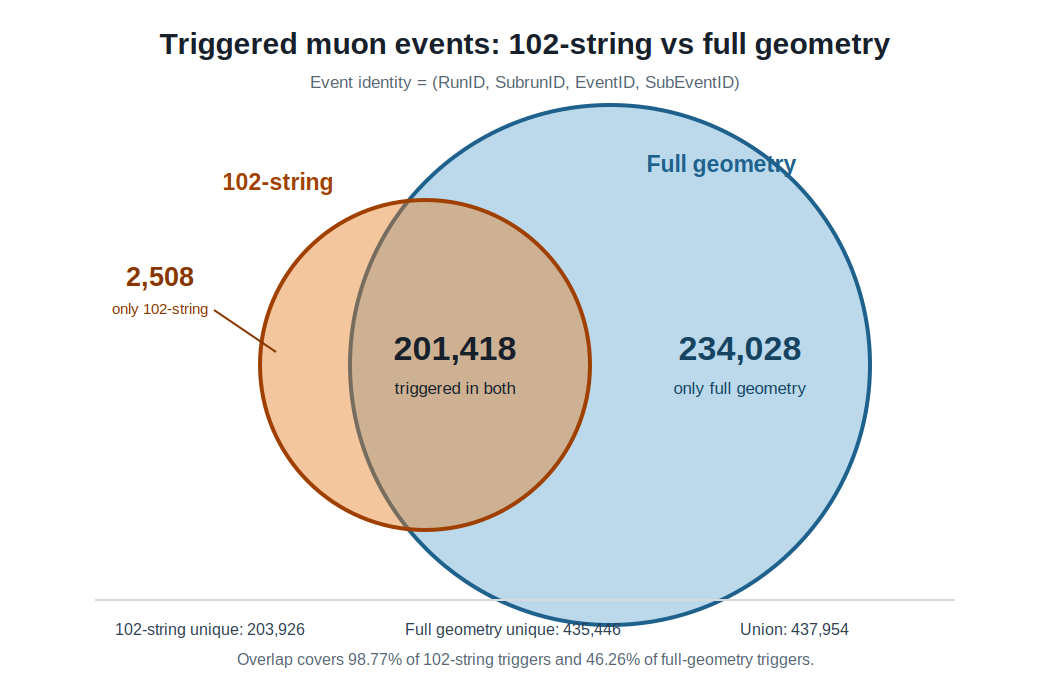

In [3]:
from IPython.display import SVG, display

only_102_count = len(only_102)
both_count = len(both)
only_full_count = len(only_full)
total_102 = len(events_102)
total_full = len(events_full)
total_union = len(union)
overlap_102 = 100 * both_count / total_102
overlap_full = 100 * both_count / total_full

svg = f'''
<svg xmlns="http://www.w3.org/2000/svg" width="1050" height="680" viewBox="0 0 1050 680">
  <rect width="1050" height="680" fill="#ffffff"/>

  <text x="525" y="54" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="30" font-weight="700" fill="#17202a">
    Triggered muon events: 102-string vs full geometry
  </text>
  <text x="525" y="88" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="17" fill="#566573">
    Event identity = (RunID, SubrunID, EventID, SubEventID)
  </text>

  <circle cx="610" cy="365" r="260" fill="#2e86c1" fill-opacity="0.32"
          stroke="#1f618d" stroke-width="4"/>
  <circle cx="425" cy="365" r="165" fill="#e67e22" fill-opacity="0.44"
          stroke="#a04000" stroke-width="4"/>

  <text x="278" y="190" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="23" font-weight="700" fill="#a04000">102-string</text>
  <text x="722" y="172" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="23" font-weight="700" fill="#1f618d">Full geometry</text>

  <line x1="276" y1="352" x2="214" y2="310" stroke="#873600" stroke-width="2"/>
  <text x="160" y="286" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="27" font-weight="700" fill="#873600">{only_102_count:,}</text>
  <text x="160" y="314" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="15" fill="#873600">only 102-string</text>

  <text x="455" y="360" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="34" font-weight="700" fill="#17202a">{both_count:,}</text>
  <text x="455" y="394" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="17" fill="#17202a">triggered in both</text>

  <text x="740" y="360" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="34" font-weight="700" fill="#154360">{only_full_count:,}</text>
  <text x="740" y="394" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="17" fill="#154360">only full geometry</text>

  <line x1="95" y1="600" x2="955" y2="600" stroke="#d5d8dc" stroke-width="2"/>
  <text x="115" y="635" text-anchor="start" font-family="Arial, Helvetica, sans-serif"
        font-size="16" fill="#2c3e50">102-string unique: {total_102:,}</text>
  <text x="405" y="635" text-anchor="start" font-family="Arial, Helvetica, sans-serif"
        font-size="16" fill="#2c3e50">Full geometry unique: {total_full:,}</text>
  <text x="740" y="635" text-anchor="start" font-family="Arial, Helvetica, sans-serif"
        font-size="16" fill="#2c3e50">Union: {total_union:,}</text>

  <text x="525" y="665" text-anchor="middle" font-family="Arial, Helvetica, sans-serif"
        font-size="16" fill="#566573">
    Overlap covers {overlap_102:.2f}% of 102-string triggers and {overlap_full:.2f}% of full-geometry triggers.
  </text>
</svg>
'''

display(SVG(data=svg))